# Merchant Clustering Notebook

This notebook performs unsupervised clustering analysis on merchants from a personal finance dataset.
The goal is to group merchants into meaningful segments based on their transaction patterns, amounts, and categories.

**Workflow:**
1. Setup & Configuration
2. Data Loading
3. Exploratory Data Analysis
4. Feature Engineering (merchant-level aggregation)
5. Preprocessing for Clustering
6. Clustering (KMeans, DBSCAN, Hierarchical)
7. Cluster Analysis & Interpretation
8. Visualization

## 1. Setup & Configuration

In [43]:
!pip install -q kagglehub xgboost lightgbm catboost

import os
import json
import time
import random
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

## 2. Data Loading

Download the dataset from Kaggle Hub and load it into a DataFrame.

In [44]:
!pip install -q kagglehub

import kagglehub
import os
import pandas as pd
path = kagglehub.dataset_download("saraswathyyy/personal-finance-dataset")
print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'personal-finance-dataset' dataset.
/kaggle/input/personal-finance-dataset
['personal_finance_dataset_8000_extended.csv']


In [45]:
df = pd.read_csv(os.path.join(path, "personal_finance_dataset_8000_extended.csv"))
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Loaded: 8000 rows x 15 columns


,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
0,2025-04-05,Transaction at IRCTC,20666.49,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night
1,2025-12-06,Transaction at Myntra,1919.05,Online Shopping,Net Banking,Hyderabad,Salary,Debit,Desktop,INR,Online Store,Yes,Saturday,December,Evening
2,2025-06-20,Transaction at BigBazaar,2837.68,Grocery,Debit Card,Bangalore,Savings,Debit,Mobile,INR,Retail,No,Friday,June,Evening
3,2025-04-23,Transaction at Property Tax Online,1071.04,Bills,Net Banking,Delhi,Current,Debit,POS Terminal,INR,Service,Yes,Wednesday,April,Afternoon
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening


## 3. Exploratory Data Analysis

In [46]:
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

print("Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("Duplicate Rows: {df.duplicated().sum()}")

print("Column Names:")
print(df.columns.tolist())

print("Data Types:")
print(df.dtypes)

print("Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    display(missing.to_frame("Missing Count"))
else:
    print("No missing values found.")

print("Unique Values per Column:")
display(df.nunique().sort_values().to_frame("Unique Values"))

num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")

DATASET OVERVIEW
Shape: {df.shape[0]} rows x {df.shape[1]} columns
Duplicate Rows: {df.duplicated().sum()}
Column Names:
['Date', 'Description', 'Amount', 'Category', 'PaymentMethod', 'Location', 'AccountType', 'TransactionType', 'DeviceUsed', 'Currency', 'MerchantType', 'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay']
Data Types:
Date                object
Description         object
Amount             float64
Category            object
PaymentMethod       object
Location            object
AccountType         object
TransactionType     object
DeviceUsed          object
Currency            object
MerchantType        object
LoyaltyProgram      object
Weekday             object
Month               object
TimeOfDay           object
dtype: object
Missing Values:
No missing values found.
Unique Values per Column:


,Unique Values
TransactionType,1
Currency,1
LoyaltyProgram,2
DeviceUsed,3
TimeOfDay,4
PaymentMethod,4
AccountType,4
MerchantType,5
Location,7
Weekday,7


Numerical Columns (1): ['Amount']
Categorical Columns (14): ['Date', 'Description', 'Category', 'PaymentMethod', 'Location', 'AccountType', 'TransactionType', 'DeviceUsed', 'Currency', 'MerchantType', 'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay']


## 4. Merchant-Level Feature Engineering

Aggregate transaction-level data to the merchant level to create clustering features.

In [47]:
df["Date"] = pd.to_datetime(df["Date"])
df["Merchant"] = df["Description"].str.replace("Transaction at ", "", regex=False)
df["Month"] = df["Date"].dt.month_name()
df["Weekday"] = df["Date"].dt.day_name()
df["TimeOfDay"] = df["TimeOfDay"].astype("category") if "TimeOfDay" in df.columns else pd.Series(["Unknown"] * len(df))
df["Location"] = df["Location"].astype("category") if "Location" in df.columns else pd.Series(["Unknown"] * len(df))
drop_cols = ["Description", "TransactionType", "Currency", "Date"]
df.drop(columns=drop_cols, inplace=True, errors="ignore")
print("Shape after preprocessing:", df.shape)
print("Sample data:")
display(df.head())

Shape after preprocessing: (8000, 12)
Sample data:


,Amount,Category,PaymentMethod,Location,AccountType,DeviceUsed,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay,Merchant
0,20666.49,Travel,Debit Card,Kolkata,Salary,Mobile,Service,No,Saturday,April,Night,IRCTC
1,1919.05,Online Shopping,Net Banking,Hyderabad,Salary,Desktop,Online Store,Yes,Saturday,December,Evening,Myntra
2,2837.68,Grocery,Debit Card,Bangalore,Savings,Mobile,Retail,No,Friday,June,Evening,BigBazaar
3,1071.04,Bills,Net Banking,Delhi,Current,POS Terminal,Service,Yes,Wednesday,April,Afternoon,Property Tax Online
4,10722.80,Electronics,Debit Card,Mumbai,Current,Mobile,Retail,Yes,Thursday,March,Evening,Asus Store


In [48]:
merchant_features = df.groupby("Merchant").agg(
    transaction_count=("Amount", "count"),
    total_amount=("Amount", "sum"),
    avg_amount=("Amount", "mean"),
    std_amount=("Amount", "std"),
    min_amount=("Amount", "min"),
    max_amount=("Amount", "max"),
    median_amount=("Amount", "median"),
    unique_categories=("Category", "nunique"),
    unique_payment_methods=("PaymentMethod", "nunique"),
    unique_locations=("Location", "nunique"),
).reset_index()

# Fill NaN std with 0 (only one transaction)
merchant_features["std_amount"] = merchant_features["std_amount"].fillna(0)

# Spending behavior ratios
merchant_features["amount_range"] = merchant_features["max_amount"] - merchant_features["min_amount"]
merchant_features["cv_amount"] = merchant_features["std_amount"] / merchant_features["avg_amount"].replace(0, np.nan)
merchant_features["cv_amount"] = merchant_features["cv_amount"].fillna(0)
merchant_features["avg_amount_log"] = np.log1p(merchant_features["avg_amount"])
merchant_features["total_amount_log"] = np.log1p(merchant_features["total_amount"])

print(f"Total unique merchants: {merchant_features.shape[0]}")
display(merchant_features.head(10))
display(merchant_features.describe())

Total unique merchants: 108


,Merchant,transaction_count,total_amount,avg_amount,std_amount,min_amount,max_amount,median_amount,unique_categories,unique_payment_methods,unique_locations,amount_range,cv_amount,avg_amount_log,total_amount_log
0,1mg,79,858330.88,10864.947848,5901.161146,143.98,19890.80,10543.340,1,4,7,19746.82,0.543138,9.293389,13.662746
1,A2B,53,45435.02,857.264528,434.541097,100.50,1492.08,923.340,1,4,7,1391.58,0.506893,6.754912,10.724060
2,ACT Fibernet,86,253721.95,2950.255233,1767.890587,229.13,5937.10,2952.415,1,4,7,5707.97,0.599233,7.989986,12.443998
3,Adidas,66,274424.78,4157.951212,2136.395648,687.83,7928.30,4395.330,1,4,7,7240.47,0.513810,8.333018,12.522436
4,Aha,86,45843.50,533.063953,275.650281,99.83,985.74,531.700,1,4,7,885.91,0.517105,6.280516,10.733011
5,Air India,79,1297253.87,16420.935063,8784.095168,1130.03,29906.37,17186.160,1,4,7,28776.34,0.534933,9.706373,14.075761
6,AirAsia,78,1237151.40,15860.915385,8350.873972,1101.08,29817.30,17172.820,1,4,7,28716.22,0.526506,9.671676,14.028323
7,Airtel,77,251428.63,3265.306883,1630.234905,262.08,5838.45,3449.000,1,4,7,5576.37,0.499259,8.091415,12.434918
8,Ajio,96,960252.21,10002.627188,5528.798352,343.12,19880.82,9788.205,1,4,7,19537.70,0.552735,9.210703,13.774952
9,Allen Solly,60,275485.02,4591.417000,2064.750776,545.49,7913.89,4651.445,1,4,7,7368.40,0.449698,8.432162,12.526292


,transaction_count,total_amount,avg_amount,std_amount,min_amount,max_amount,median_amount,unique_categories,unique_payment_methods,unique_locations,amount_range,cv_amount,avg_amount_log,total_amount_log
count,108.000000,1.080000e+02,108.000000,108.000000,108.000000,108.000000,108.000000,108.0,108.0,108.0,108.000000,108.000000,108.000000,108.000000
mean,74.074074,9.297744e+05,13882.520207,7596.625344,977.689630,26521.234537,14151.343148,1.0,4.0,7.0,25543.544907,0.531720,8.377068,12.660818
std,14.687208,1.493051e+06,24173.460619,13209.519547,1981.216506,46025.122261,24987.060407,0.0,0.0,0.0,44291.384164,0.054912,1.517941,1.517542
min,45.000000,3.394009e+04,496.008267,240.298812,54.110000,956.580000,457.000000,1.0,4.0,7.0,853.070000,0.400222,6.208607,10.432382
25%,62.750000,8.114009e+04,1016.052167,546.659184,125.770000,1974.072500,1048.525000,1.0,4.0,7.0,1885.292500,0.499236,6.924414,11.303884
50%,77.000000,2.624350e+05,3872.934358,2012.394617,243.335000,7810.545000,3591.082500,1.0,4.0,7.0,7197.060000,0.536676,8.261905,12.477760
75%,86.000000,8.899614e+05,10750.162157,5969.790215,632.530000,19930.187500,11046.462500,1.0,4.0,7.0,19590.865000,0.572977,9.282750,13.698785
max,111.000000,6.206967e+06,93045.270645,44746.842498,12172.110000,149925.200000,97857.550000,1.0,4.0,7.0,146448.430000,0.656180,11.440852,15.641183


## 5. Preprocessing for Clustering

Select numerical features, handle missing values, and scale to prepare for clustering algorithms.

In [49]:
# Select numerical features for clustering
feature_cols = [
    "transaction_count", "total_amount", "avg_amount", "std_amount",
    "min_amount", "max_amount", "median_amount", "unique_categories",
    "unique_payment_methods", "unique_locations",
    "amount_range", "cv_amount", "avg_amount_log", "total_amount_log"
]

X = merchant_features[feature_cols].copy()

# Handle remaining NaN
X = X.fillna(X.median())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features: {feature_cols}")
print(f"Scaled data statistics:")
print(pd.DataFrame(X_scaled, columns=feature_cols).describe().round(3))

Feature matrix shape: (108, 14)
Features: ['transaction_count', 'total_amount', 'avg_amount', 'std_amount', 'min_amount', 'max_amount', 'median_amount', 'unique_categories', 'unique_payment_methods', 'unique_locations', 'amount_range', 'cv_amount', 'avg_amount_log', 'total_amount_log']
Scaled data statistics:
       transaction_count  total_amount  avg_amount  std_amount  min_amount  \
count            108.000       108.000     108.000     108.000     108.000   
mean              -0.000        -0.000       0.000      -0.000      -0.000   
std                1.005         1.005       1.005       1.005       1.005   
min               -1.989        -0.603      -0.556      -0.559      -0.468   
25%               -0.775        -0.571      -0.535      -0.536      -0.432   
50%                0.200        -0.449      -0.416      -0.425      -0.372   
75%                0.816        -0.027      -0.130      -0.124      -0.175   
max                2.526         3.551       3.290       2.825   

## 6. Determining Optimal Number of Clusters

Use the elbow method, silhouette analysis, and Davies-Bouldin index to evaluate cluster count candidates.

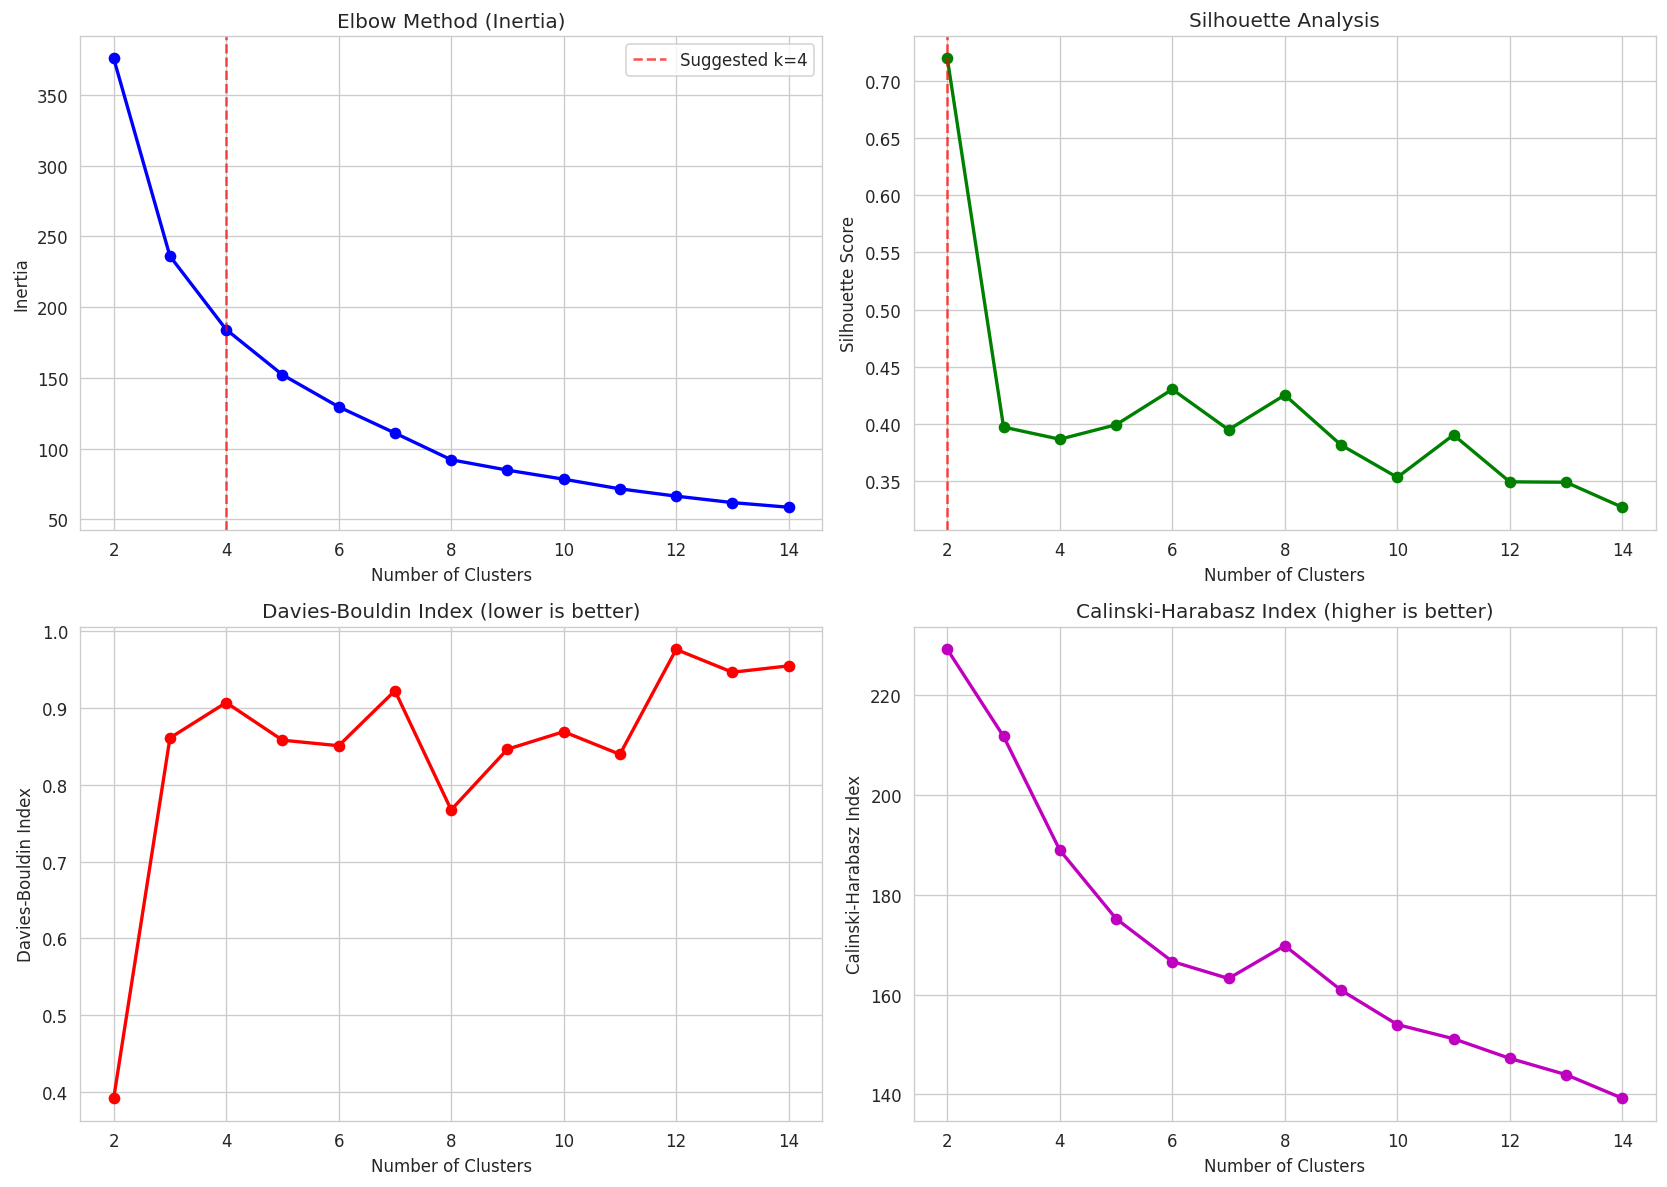

Best Silhouette Score: 0.7194 at k=2
Best Davies-Bouldin: 0.3917 at k=2
Best Calinski-Harabasz: 229.1462 at k=2


In [50]:
range_n_clusters = range(2, 15)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []

for n_clusters in range_n_clusters:
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))

# Elbow plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(range_n_clusters, inertias, "bo-", linewidth=2)
axes[0, 0].set_xlabel("Number of Clusters")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_title("Elbow Method (Inertia)")
axes[0, 0].axvline(x=4, color="r", linestyle="--", alpha=0.7, label="Suggested k=4")
axes[0, 0].legend()

axes[0, 1].plot(range_n_clusters, silhouette_scores, "go-", linewidth=2)
axes[0, 1].set_xlabel("Number of Clusters")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_title("Silhouette Analysis")
axes[0, 1].axvline(x=silhouette_scores.index(max(silhouette_scores)) + 2, color="r", linestyle="--", alpha=0.7)

axes[1, 0].plot(range_n_clusters, davies_bouldin_scores, "ro-", linewidth=2)
axes[1, 0].set_xlabel("Number of Clusters")
axes[1, 0].set_ylabel("Davies-Bouldin Index")
axes[1, 0].set_title("Davies-Bouldin Index (lower is better)")

axes[1, 1].plot(range_n_clusters, calinski_scores, "mo-", linewidth=2)
axes[1, 1].set_xlabel("Number of Clusters")
axes[1, 1].set_ylabel("Calinski-Harabasz Index")
axes[1, 1].set_title("Calinski-Harabasz Index (higher is better)")

plt.tight_layout()
plt.show()

print(f"Best Silhouette Score: {max(silhouette_scores):.4f} at k={silhouette_scores.index(max(silhouette_scores)) + 2}")
print(f"Best Davies-Bouldin: {min(davies_bouldin_scores):.4f} at k={davies_bouldin_scores.index(min(davies_bouldin_scores)) + 2}")
print(f"Best Calinski-Harabasz: {max(calinski_scores):.4f} at k={calinski_scores.index(max(calinski_scores)) + 2}")

## 7. Applying Clustering Algorithms

Apply KMeans, DBSCAN, and Hierarchical Clustering and compare results.

In [51]:
# ---- KMeans ----
best_k = silhouette_scores.index(max(silhouette_scores)) + 2
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"KMeans (k={best_k}) Silhouette Score: {kmeans_silhouette:.4f}")

# ---- DBSCAN ----
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_dbscan_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN: {n_dbscan_clusters} clusters, {n_dbscan_noise} noise points ({(n_dbscan_noise/len(dbscan_labels)*100):.1f}%)")

if n_dbscan_clusters > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")
else:
    dbscan_silhouette = -1
    print("DBSCAN Silhouette Score: N/A (need at least 2 clusters)")

# ---- Hierarchical ----
hier = AgglomerativeClustering(n_clusters=best_k)
hier_labels = hier.fit_predict(X_scaled)
hier_silhouette = silhouette_score(X_scaled, hier_labels)
print(f"Hierarchical (k={best_k}) Silhouette Score: {hier_silhouette:.4f}")

KMeans (k=2) Silhouette Score: 0.7194
DBSCAN: 4 clusters, 76 noise points (70.4%)
DBSCAN Silhouette Score: -0.1628
Hierarchical (k=2) Silhouette Score: 0.7194


## 8. Cluster Analysis

Assign cluster labels to merchants and analyze the characteristics of each cluster.

In [52]:
# Use KMeans as the primary clustering result
merchant_features["cluster"] = kmeans_labels

print(f"Cluster Distribution:")
cluster_counts = merchant_features["cluster"].value_counts().sort_index()
display(cluster_counts.to_frame("Merchant Count").rename(columns={"cluster": "Cluster"}))

# Profile each cluster
print("Cluster Profiles (Mean Values):")
cluster_profile = merchant_features.groupby("cluster")[feature_cols].mean()
display(cluster_profile.round(3))

# Cluster sizes
print("Cluster Sizes:")
for c in sorted(merchant_features["cluster"].unique()):
    subset = merchant_features[merchant_features["cluster"] == c]
    print(f"  Cluster {c}: {len(subset)} merchants")
    print(f"    Avg transactions: {subset['transaction_count'].mean():.1f}")
    print(f"    Avg amount: ${subset['avg_amount'].mean():.2f}")
    print(f"    Total spend: ${subset['total_amount'].sum():.2f}")

Cluster Distribution:


,Merchant Count
cluster,
0,13
1,95


Cluster Profiles (Mean Values):


,transaction_count,total_amount,avg_amount,std_amount,min_amount,max_amount,median_amount,unique_categories,unique_payment_methods,unique_locations,amount_range,cv_amount,avg_amount_log,total_amount_log
cluster,,,,,,,,,,,,,,
0,61.308,4758759.042,77463.002,42385.554,5663.443,147958.073,79717.750,1.0,4.0,7.0,142294.630,0.550,11.255,15.365
1,75.821,405808.089,5182.033,2836.035,336.481,9903.562,5179.098,1.0,4.0,7.0,9567.081,0.529,7.983,12.291


Cluster Sizes:
  Cluster 0: 13 merchants
    Avg transactions: 61.3
    Avg amount: $77463.00
    Total spend: $61863867.55
  Cluster 1: 95 merchants
    Avg transactions: 75.8
    Avg amount: $5182.03
    Total spend: $38551768.48


## 9. Dimensionality Reduction for Visualization

Use PCA to project merchant features into 2D for cluster visualization.

Explained variance ratio: [0.7532129  0.13445593]
Total variance explained: 0.8877


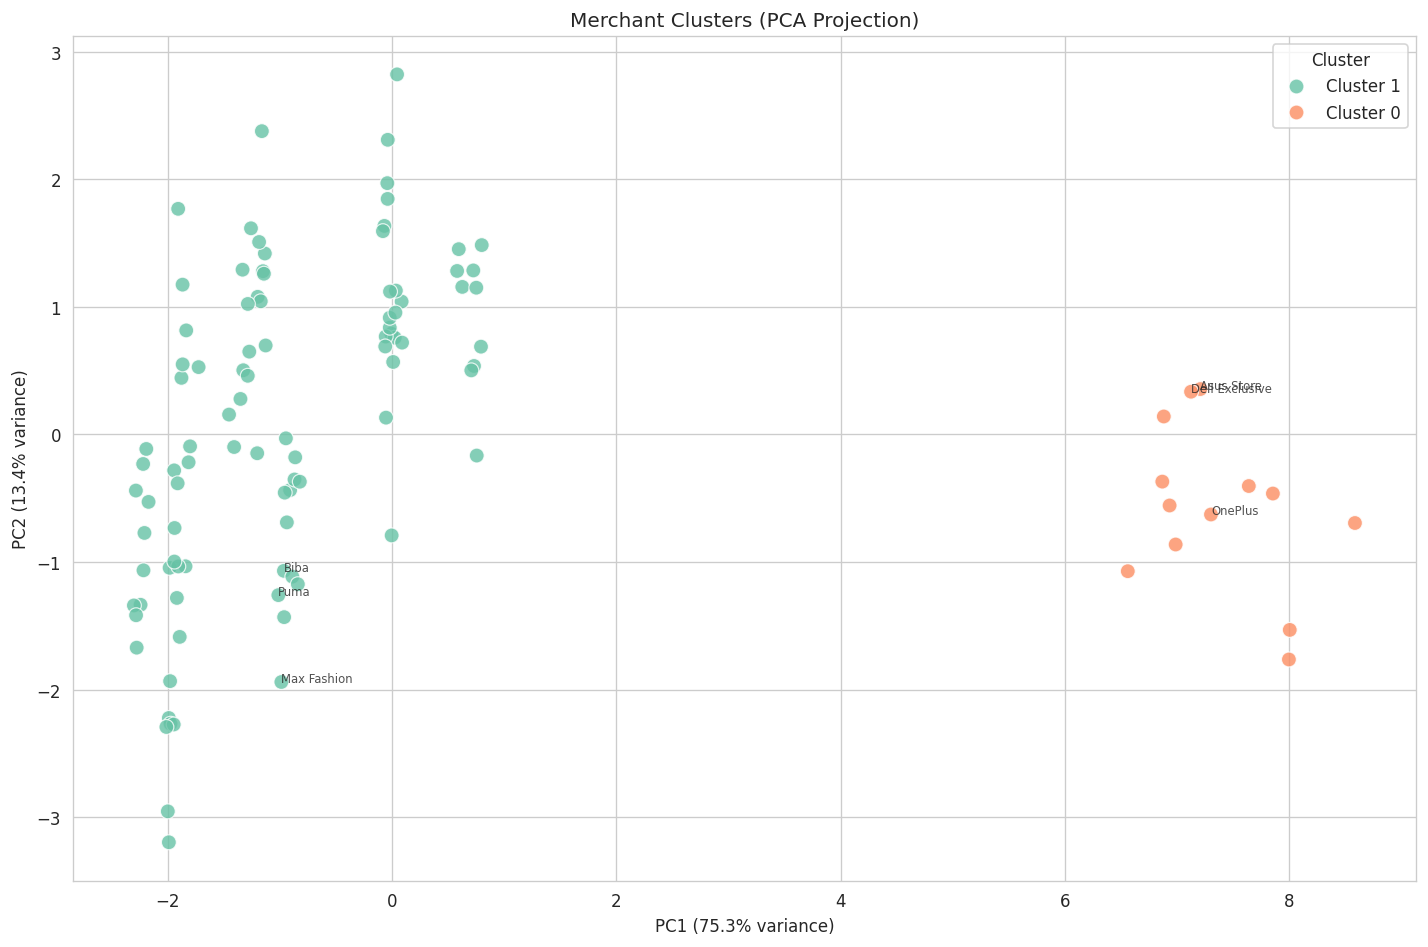

In [53]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame for plotting
viz_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": [f"Cluster {c}" for c in kmeans_labels],
    "Merchant": merchant_features["Merchant"].values
})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=80, alpha=0.8)

# Annotate a few key merchants
key_merchants = viz_df.groupby("Cluster").apply(
    lambda g: g.loc[(g["PC1"] - g["PC1"].mean()).abs().nsmallest(3).index]
).reset_index(drop=True)
for _, row in key_merchants.head(15).iterrows():
    plt.annotate(row["Merchant"][:20], (row["PC1"], row["PC2"]), fontsize=7, alpha=0.8)

plt.title("Merchant Clusters (PCA Projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 10. Cluster Visualizations

Dendrogram, cluster feature profiles, and per-cluster distributions.

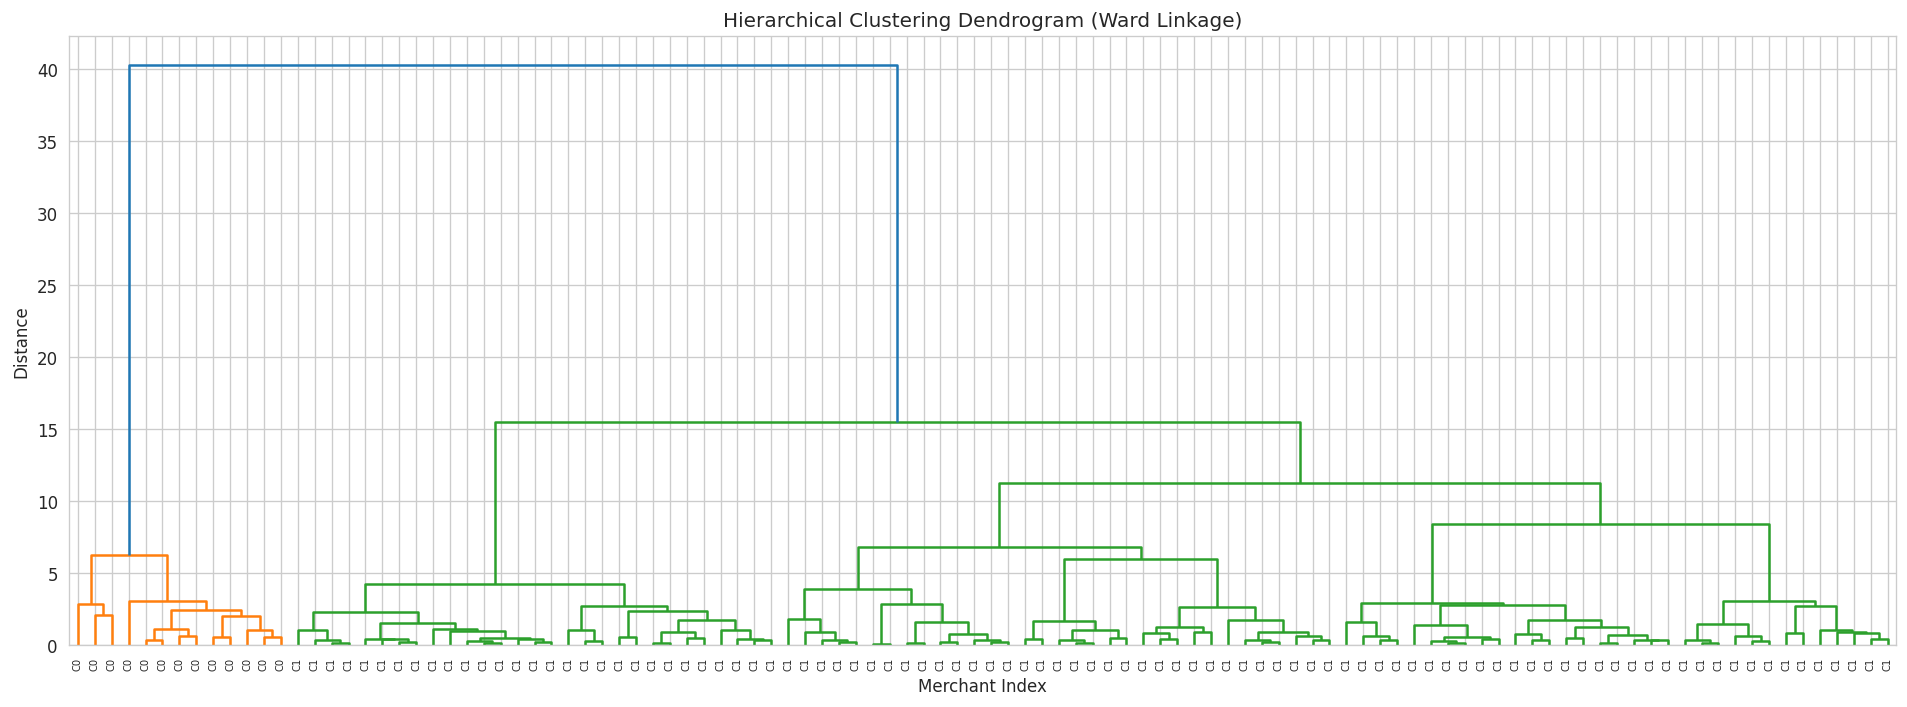

In [54]:
# Dendrogram
plt.figure(figsize=(16, 6))
linked = linkage(X_scaled, method="ward")
dendrogram(linked, labels=[f"C{i}" for i in kmeans_labels], leaf_rotation=90, leaf_font_size=6)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Merchant Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

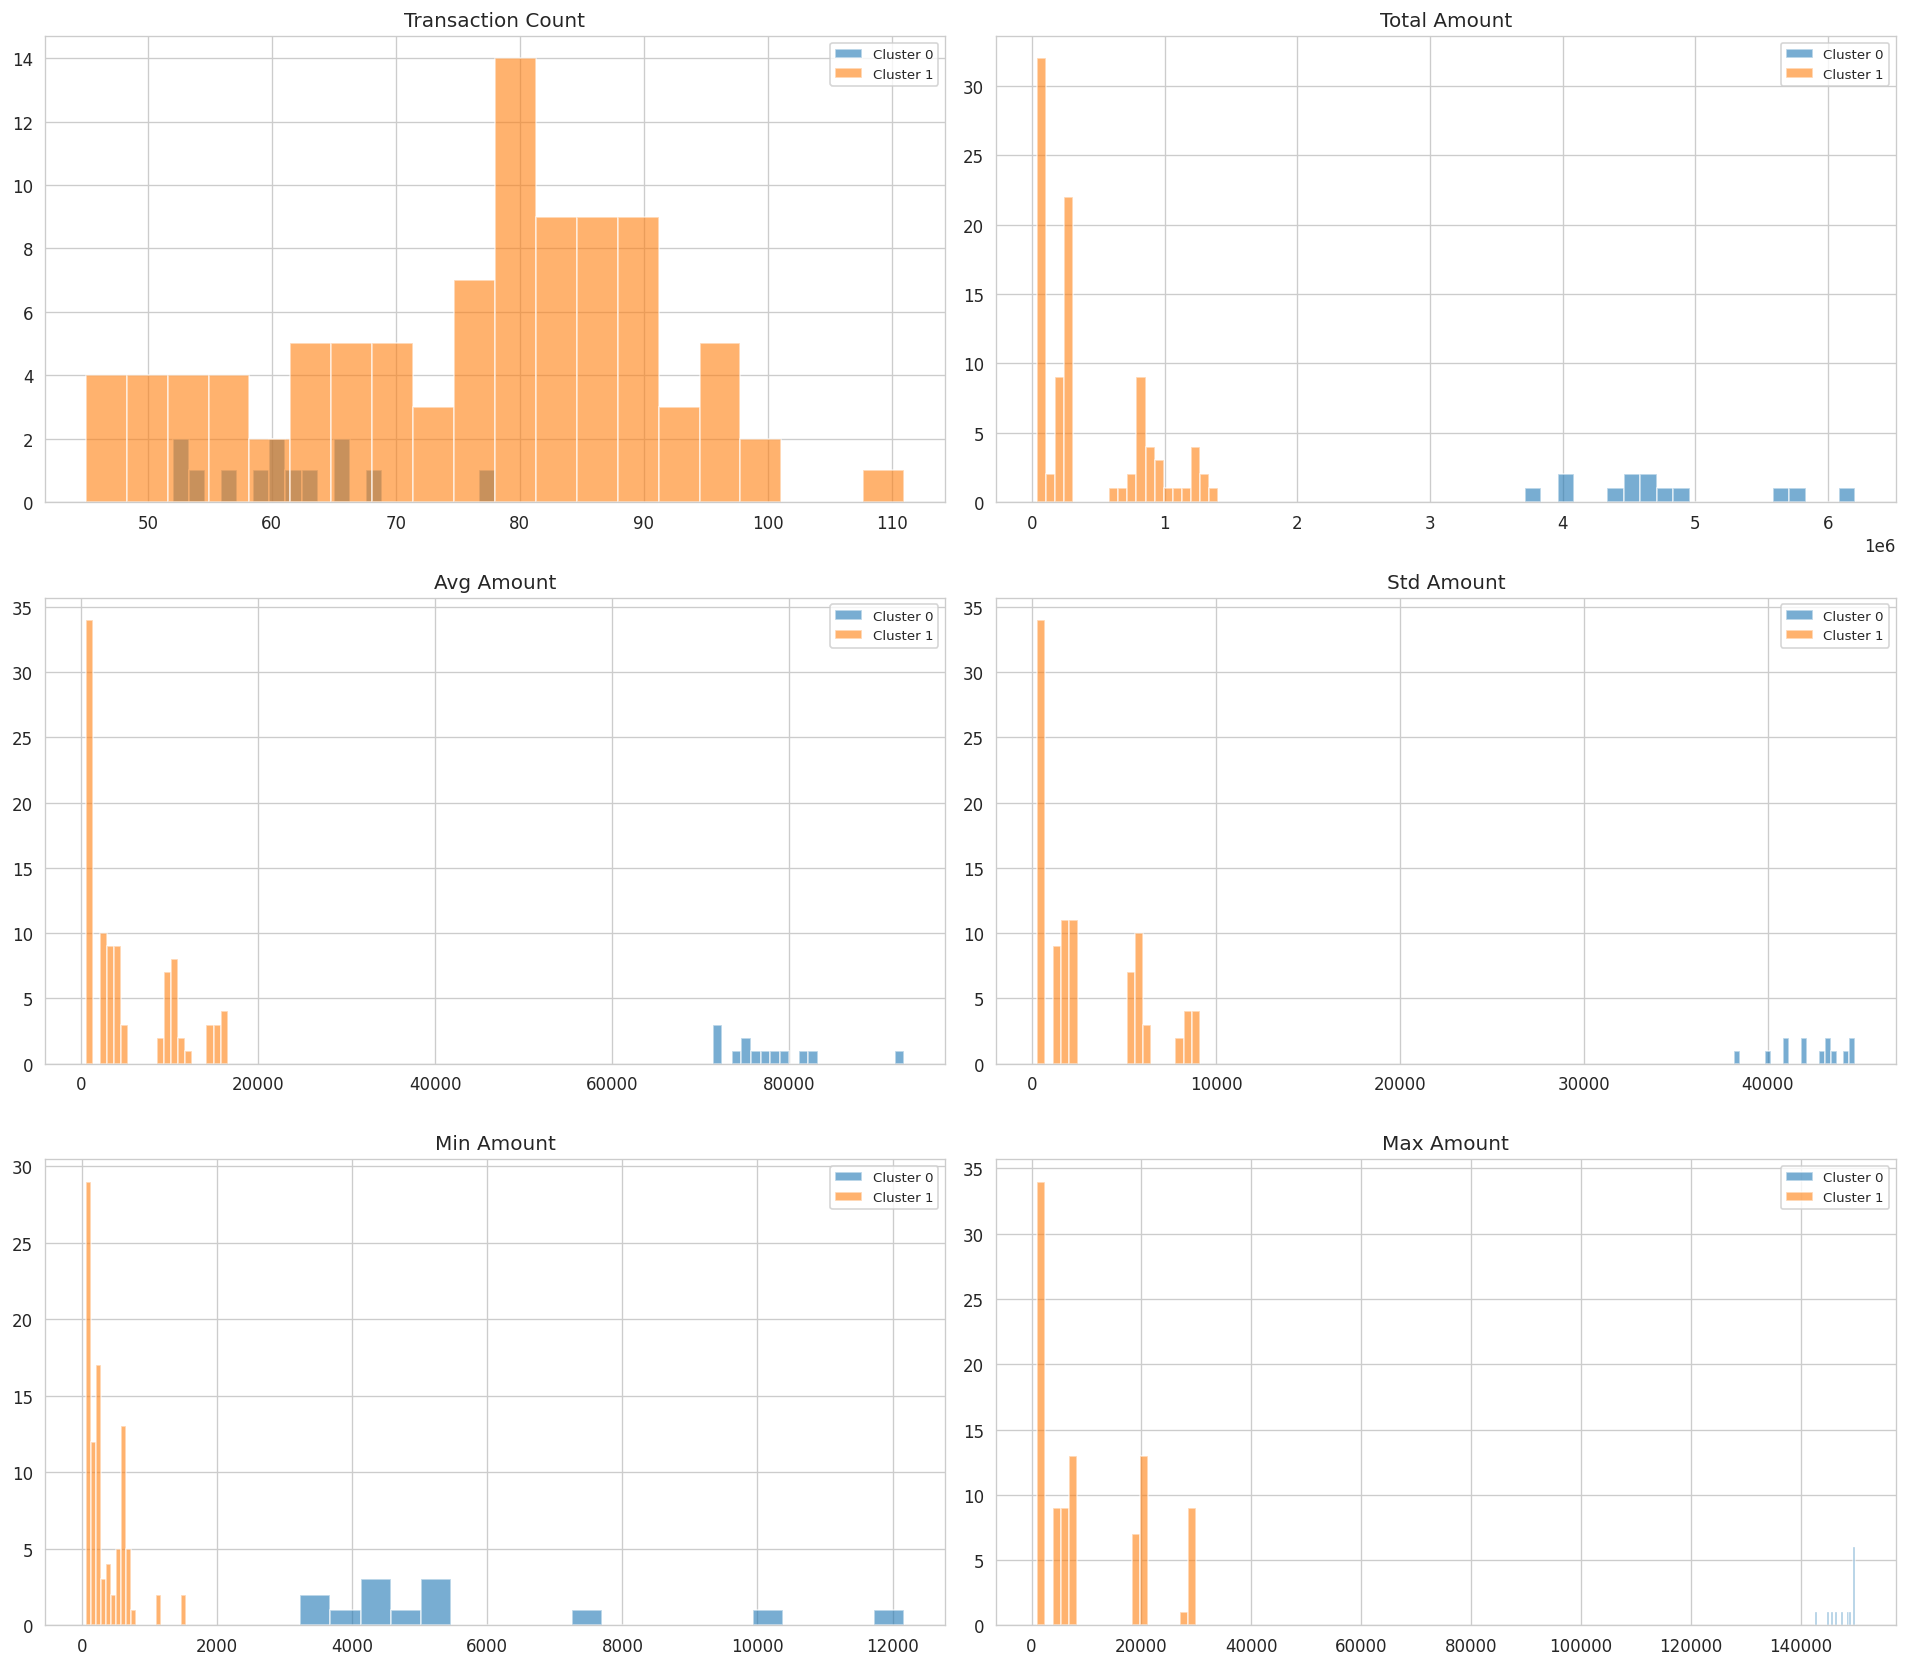

In [55]:
# Cluster feature radar-style profiles
cluster_means = merchant_features.groupby("cluster")[feature_cols].mean()
cluster_stds = merchant_features.groupby("cluster")[feature_cols].std()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, feat in enumerate(feature_cols[:6]):
    ax = axes[idx]
    for c in sorted(merchant_features["cluster"].unique()):
        vals = merchant_features[merchant_features["cluster"] == c][feat]
        ax.hist(vals, bins=20, alpha=0.6, label=f"Cluster {c}")
    ax.set_title(feat.replace("_", " ").title())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

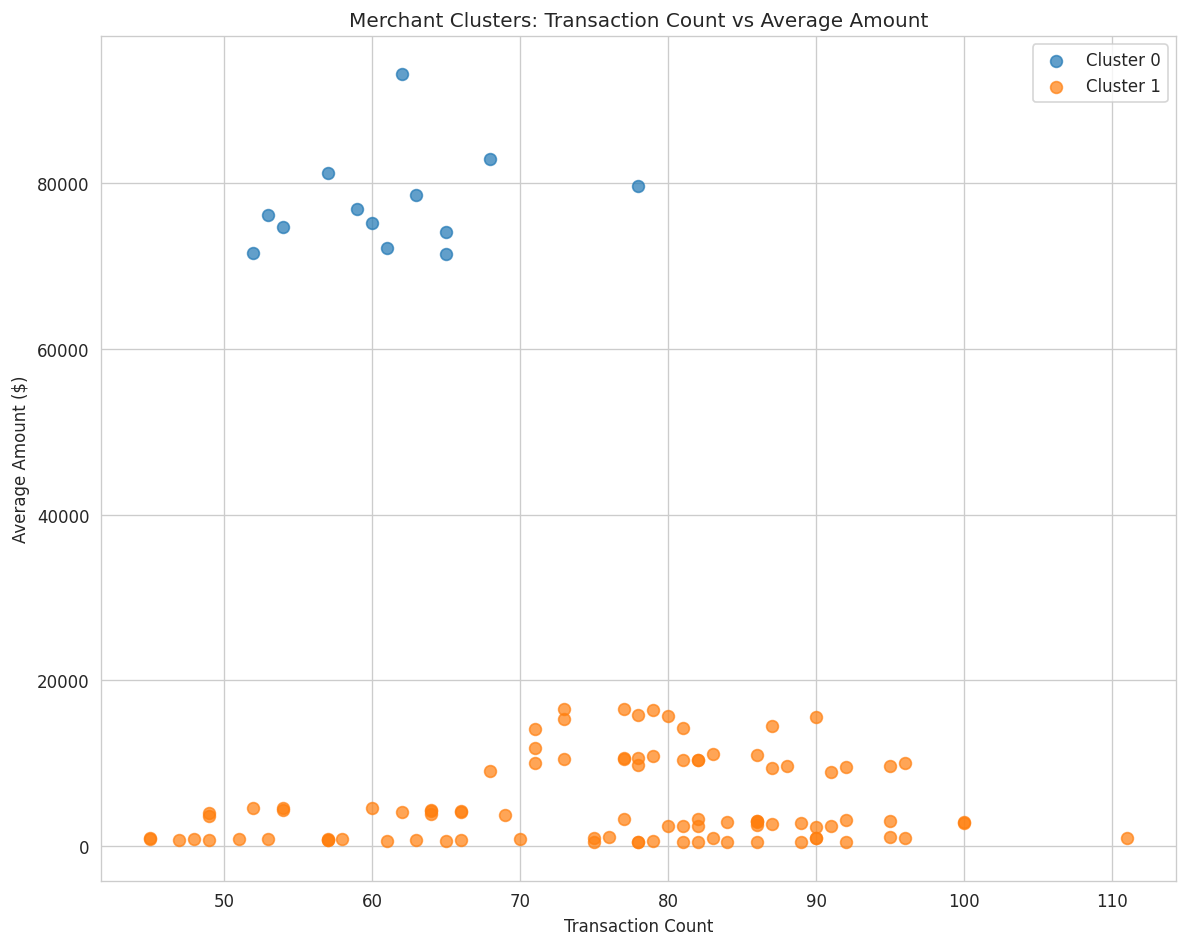

In [56]:
# Transaction count vs avg amount colored by cluster
plt.figure(figsize=(10, 8))
for c in sorted(merchant_features["cluster"].unique()):
    subset = merchant_features[merchant_features["cluster"] == c]
    plt.scatter(subset["transaction_count"], subset["avg_amount"],
                label=f"Cluster {c}", alpha=0.7, s=50)

plt.xlabel("Transaction Count")
plt.ylabel("Average Amount ($)")
plt.title("Merchant Clusters: Transaction Count vs Average Amount")
plt.legend()
plt.tight_layout()
plt.show()

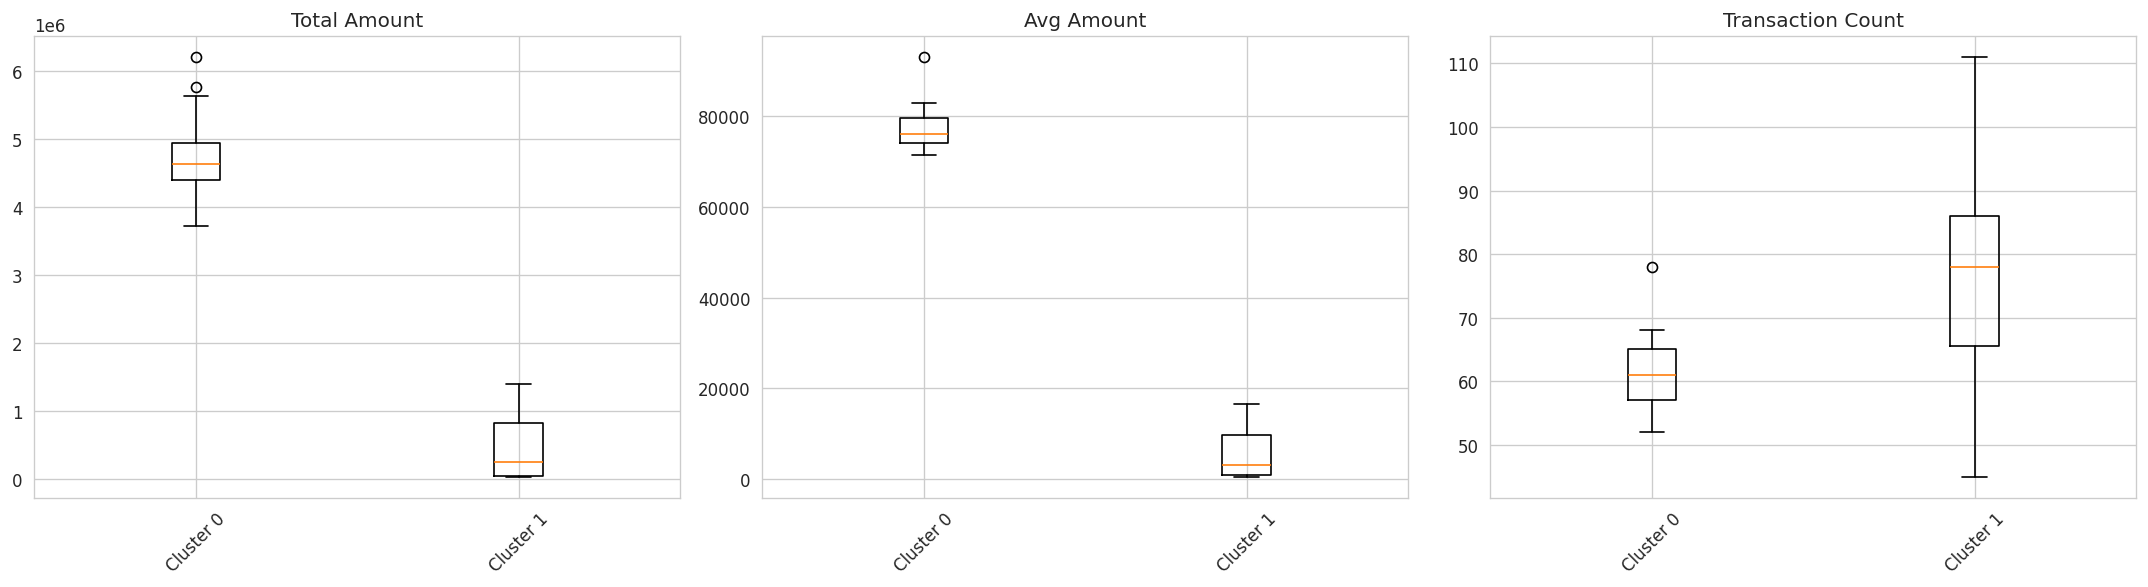

In [57]:
# Spending distribution per cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(["total_amount", "avg_amount", "transaction_count"]):
    axes[idx].boxplot([merchant_features[merchant_features["cluster"] == c][col].dropna()
                        for c in sorted(merchant_features["cluster"].unique())],
                      labels=[f"Cluster {c}" for c in sorted(merchant_features["cluster"].unique())])
    axes[idx].set_title(col.replace("_", " ").title())
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 11. Clustering Evaluation Summary

In [58]:
print("=" * 80)
print("CLUSTERING EVALUATION SUMMARY")
print("=" * 80)

print(f"KMeans (k={best_k}):")
print(f"  Silhouette Score:        {kmeans_silhouette:.4f}")
print(f"  Davies-Bouldin Index:    {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")
print(f"  Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}")

print(f"DBSCAN (eps=0.5, min_samples=5):")
print(f"  Clusters Found:          {n_dbscan_clusters}")
print(f"  Noise Points:            {n_dbscan_noise} ({(n_dbscan_noise/len(dbscan_labels)*100):.1f}%)")
if n_dbscan_clusters > 1:
    print(f"  Silhouette Score:        {dbscan_silhouette:.4f}")

print(f"Hierarchical (k={best_k}):")
print(f"  Silhouette Score:        {hier_silhouette:.4f}")
print(f"  Davies-Bouldin Index:    {davies_bouldin_score(X_scaled, hier_labels):.4f}")
print(f"  Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, hier_labels):.4f}")

CLUSTERING EVALUATION SUMMARY
KMeans (k=2):
  Silhouette Score:        0.7194
  Davies-Bouldin Index:    0.3917
  Calinski-Harabasz Index: 229.1462
DBSCAN (eps=0.5, min_samples=5):
  Clusters Found:          4
  Noise Points:            76 (70.4%)
  Silhouette Score:        -0.1628
Hierarchical (k=2):
  Silhouette Score:        0.7194
  Davies-Bouldin Index:    0.3917
  Calinski-Harabasz Index: 229.1462


## 12. Persistence

Save the clustering results, scaler, and cluster profiles for future use.

In [59]:
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Save merchant features with cluster assignments
merchant_features.to_csv("models/merchant_clusters.csv", index=False)

# Save scaler
joblib.dump(scaler, "models/clustering_scaler.pkl")

# Save the KMeans model
joblib.dump(kmeans, "models/kmeans_model.pkl")

# Save cluster profiles
cluster_profile.to_csv("models/cluster_profiles.csv")

# Save feature columns for reference
joblib.dump(feature_cols, "models/feature_columns.pkl")

# Save metadata
metadata = {
    "num_merchants": int(len(merchant_features)),
    "num_clusters": int(best_k),
    "algorithm": "KMeans",
    "silhouette_score": float(kmeans_silhouette),
    "davies_bouldin_score": float(davies_bouldin_score(X_scaled, kmeans_labels)),
    "calinski_harabasz_score": float(calinski_harabasz_score(X_scaled, kmeans_labels)),
    "features_used": feature_cols,
    "cluster_distribution": {int(k): int(v) for k, v in cluster_counts.items()},
    "pca_explained_variance": [float(x) for x in pca.explained_variance_ratio_]
}
with open("models/clustering_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved Files:")
print("  models/merchant_clusters.csv")
print("  models/clustering_scaler.pkl")
print("  models/kmeans_model.pkl")
print("  models/cluster_profiles.csv")
print("  models/feature_columns.pkl")
print("  models/clustering_metadata.json")
print("Clustering complete!")

Saved Files:
  models/merchant_clusters.csv
  models/clustering_scaler.pkl
  models/kmeans_model.pkl
  models/cluster_profiles.csv
  models/feature_columns.pkl
  models/clustering_metadata.json
Clustering complete!
